In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import re
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,Dense,Dropout,Flatten
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,classification_report

In [3]:
df=pd.read_csv("/content/complaints_processed.csv")
df

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
...,...,...,...
162416,162416,debt_collection,name
162417,162417,credit_card,name
162418,162418,debt_collection,name
162419,162419,credit_card,name


In [4]:
df.drop(columns='Unnamed: 0',axis=1,inplace=True)

In [5]:
df.tail(10)

,product,narrative
162411,retail_banking,zelle suspended account without cause banking ...
162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...
162414,debt_collection,zuntafi sent notice willing settle defaulted s...
162415,debt_collection,name
162416,debt_collection,name
162417,credit_card,name
162418,debt_collection,name
162419,credit_card,name
162420,credit_reporting,name


In [6]:
df=df[df['narrative']!='name']
df

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...
...,...,...
162410,credit_reporting,zales comenity bank closed sold account report...
162411,retail_banking,zelle suspended account without cause banking ...
162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162415 entries, 0 to 162414
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   product    162415 non-null  object
 1   narrative  162405 non-null  object
dtypes: object(2)
memory usage: 3.7+ MB


In [8]:
df.describe(include='O')

,product,narrative
count,162415,162405
unique,5,124471
top,credit_reporting,victim identity notified collection creditor s...
freq,91178,739


In [9]:
df.duplicated().sum()

np.int64(37739)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.isna().sum()

,0
product,0
narrative,3


In [12]:
df.dropna(subset=['narrative'],inplace=True)

In [13]:
df.reset_index(drop=True,inplace=True)

In [14]:
df['product'].unique()

array(['credit_card', 'retail_banking', 'credit_reporting',
       'mortgages_and_loans', 'debt_collection'], dtype=object)

In [15]:
df1=df['product'].value_counts()
df1

,count
product,
credit_reporting,56302
debt_collection,21116
mortgages_and_loans,18759
credit_card,15023
retail_banking,13473


Text(0.5, 1.0, 'Product Value Count')

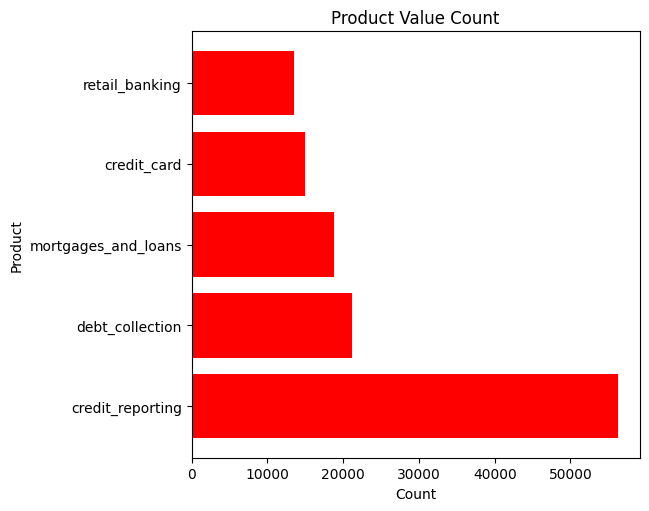

In [16]:
plt.barh(df1.index,df1.values,color='r')
plt.tight_layout()
plt.xlabel('Count')
plt.ylabel('Product')
plt.title('Product Value Count')

In [17]:
encoder=LabelEncoder()
df['product']=encoder.fit_transform(df['product'])

In [18]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\n',' ',text)
    text=re.sub(r'\s+',' ',text)
    return text

df['narrative']=df['narrative'].apply(clean_text)

In [19]:
df

,product,narrative
0,0,purchase order day shipping amount receive pro...
1,0,forwarded message date tue subject please inve...
2,4,forwarded message cc sent friday pdt subject f...
3,1,payment history missing credit report speciali...
4,1,payment history missing credit report made mis...
...,...,...
124668,1,zales comenity bank closed sold account report...
124669,4,zelle suspended account without cause banking ...
124670,2,zero contact made debt supposedly resolved fou...
124671,3,zillow home loan nmls nmls actual quote provid...


In [20]:
x=df['narrative']
y=df['product']

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
x_train

,narrative
6213,bank huntington pandemic first began placed lo...
59605,victim identity fraud filed police report told...
19493,hello making complaint clear path lending part...
106990,first time identity compromised please remove ...
91181,please check wire transfer sent fraud induce w...
...,...
31630,earned reward jcp store toward future purchase...
35251,bank america prepaid card provided edd underem...
40894,disputed erroneous information credit bureau e...
39335,separated husband since renovate apartment you...


In [22]:
max_words=10000
max_len=200
tokenize=Tokenizer(num_words=max_words,oov_token='<OOV>')
tokenize.fit_on_texts(x_train)
x_train_seq=tokenize.texts_to_sequences(x_train)
x_test_seq=tokenize.texts_to_sequences(x_test)
x_train_pad=pad_sequences(x_train_seq,maxlen=max_len,padding='post')
x_test_pad=pad_sequences(x_test_seq,maxlen=max_len,padding='post')

In [23]:
from tensorflow.keras.layers import LSTM, Bidirectional

num_classes = y_train.nunique()
ann = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

In [24]:
ann.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [25]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [26]:
ann.fit(x_train_pad,y_train,batch_size=32,epochs=20,validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 100s 36ms/step - accuracy: 0.7780 - loss: 0.6518 - val_accuracy: 0.8354 - val_loss: 0.4871
Epoch 2/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 91s 36ms/step - accuracy: 0.8430 - loss: 0.4754 - val_accuracy: 0.8431 - val_loss: 0.4462
Epoch 3/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 93s 37ms/step - accuracy: 0.8635 - loss: 0.4110 - val_accuracy: 0.8434 - val_loss: 0.4421
Epoch 4/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 92s 37ms/step - accuracy: 0.8759 - loss: 0.3696 - val_accuracy: 0.8486 - val_loss: 0.4512
Epoch 5/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 106s 42ms/step - accuracy: 0.8898 - loss: 0.3287 - val_accuracy: 0.8493 - val_loss: 0.4407
Epoch 6/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 109s 44ms/step - accuracy: 0.9020 - loss: 0.2882 - val_accuracy: 0.8509 - val_loss: 0.4631
Epoch 7/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 97s 39ms/step - accuracy: 0.9151 - loss: 0.2509 - val_accuracy: 0.8485 - val_loss: 0.5016
Epoch 8/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 137s 37ms/step - accuracy: 0.92

In [28]:
y_pred_new = np.argmax(ann.predict(x_test_pad), axis=1)
print("New Accuracy Score:", accuracy_score(y_test, y_pred_new) * 100)
print("\nNew Classification Report:\n", classification_report(y_test, y_pred_new))

780/780 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step
New Accuracy Score: 84.93683577300982

New Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77      3005
           1       0.89      0.89      0.89     11260
           2       0.80      0.79      0.79      4223
           3       0.84      0.83      0.84      3752
           4       0.82      0.91      0.86      2695

    accuracy                           0.85     24935
   macro avg       0.83      0.83      0.83     24935
weighted avg       0.85      0.85      0.85     24935



In [29]:
y_pred_prob=ann.predict(x_test_pad)
y_pred_prob

780/780 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step


array([[1.1897411e-05, 9.9960035e-01, 3.7417078e-04, 1.3329681e-05,
        2.0702272e-07],
       [2.1131193e-02, 6.2637192e-01, 2.8384054e-01, 6.3135840e-02,
        5.5205375e-03],
       [1.2203946e-03, 9.9052083e-01, 8.0395835e-03, 1.7898456e-04,
        4.0258372e-05],
       ...,
       [2.6455389e-02, 7.7516121e-01, 1.8849590e-01, 7.8654038e-03,
        2.0219947e-03],
       [2.4826810e-04, 9.9757892e-01, 2.1205212e-03, 4.5758414e-05,
        6.5414415e-06],
       [2.3402592e-02, 7.9884760e-02, 8.3911949e-01, 5.1517837e-02,
        6.0752258e-03]], dtype=float32)

In [30]:
y_pred=np.argmax(y_pred_prob,axis=1)
y_pred

array([1, 1, 1, ..., 1, 1, 2])

In [31]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[ 2258,   263,    79,    65,   340],
       [  266, 10028,   623,   275,    68],
       [  113,   549,  3338,   185,    38],
       [   54,   383,   117,  3114,    84],
       [  139,    46,    19,    50,  2441]])

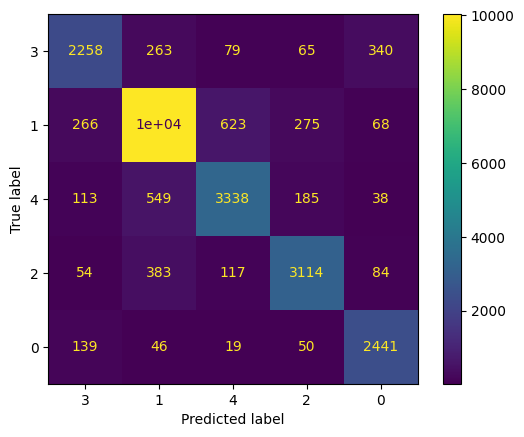

In [32]:
lab=[3,1,4,2,0]
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)
cmd.plot()

In [33]:
score=accuracy_score(y_test,y_pred)*100
score

84.93683577300982

In [34]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.80      0.75      0.77      3005
           1       0.89      0.89      0.89     11260
           2       0.80      0.79      0.79      4223
           3       0.84      0.83      0.84      3752
           4       0.82      0.91      0.86      2695

    accuracy                           0.85     24935
   macro avg       0.83      0.83      0.83     24935
weighted avg       0.85      0.85      0.85     24935



In [35]:
ann.save('Rnn_model.keras')